# IMPORT LIBRARIES

# STEP : 1

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\Unsupervised Learning\online_retail_II.csv")

In [3]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [4]:
df.shape

(1067371, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [7]:
df = df[df['Country'] == 'United Kingdom']
print("Rows after UK filtering:", len(df))

Rows after UK filtering: 981330


In [8]:
before = len(df)

df = df.dropna(subset=['Customer ID'])

print("Rows dropped:", before - len(df))

Rows dropped: 240029


In [9]:
before = len(df)

df = df[df['Quantity'] > 0]

print("Rows dropped:", before - len(df))

Rows dropped: 16005


In [10]:
before = len(df)

df = df[df['Price'] > 0]

print("Rows dropped:", before - len(df))

Rows dropped: 46


In [11]:
df['TotalPrice'] = df['Quantity'] * df['Price']

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


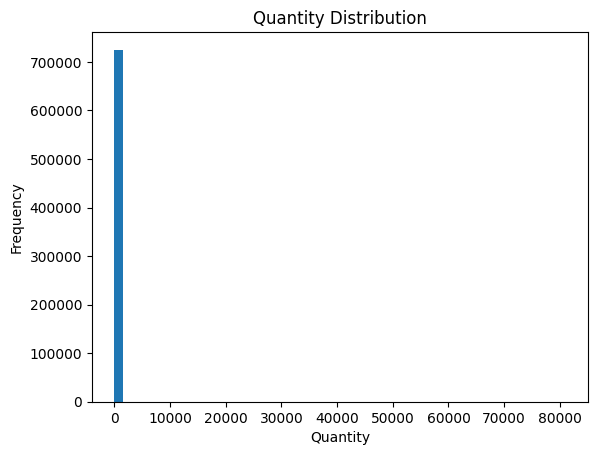

In [12]:
plt.hist(df['Quantity'], bins=50)
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.title('Quantity Distribution')
plt.show()

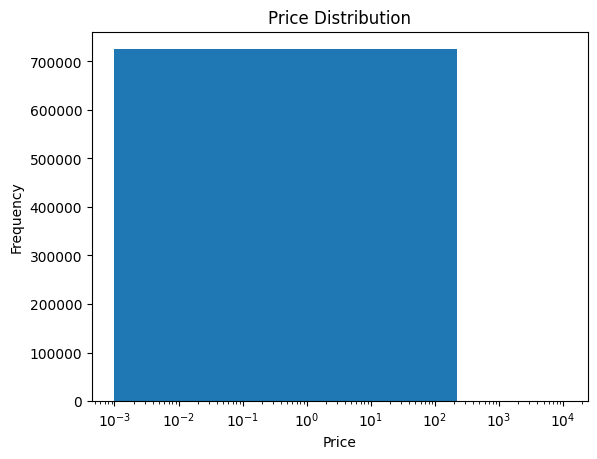

In [13]:
plt.hist(df['Price'], bins=50)
plt.xscale('log')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution')
plt.show()

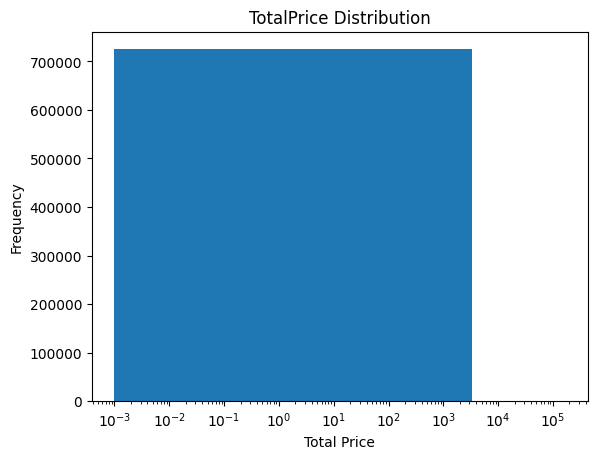

In [14]:
plt.hist(df['TotalPrice'], bins=50)
plt.xscale('log')
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.title('TotalPrice Distribution')
plt.show()

In [16]:
original = pd.read_csv(r"D:\Unsupervised Learning\online_retail_II.csv")

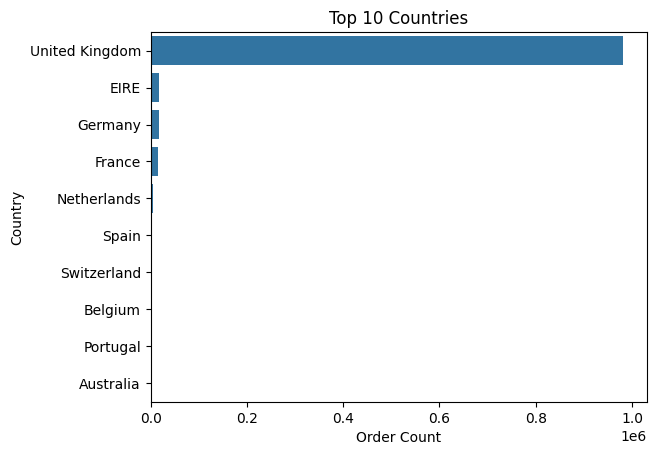

In [17]:
top10 = original['Country'].value_counts().head(10)

sns.barplot(x=top10.values, y=top10.index)
plt.xlabel('Order Count')
plt.ylabel('Country')
plt.title('Top 10 Countries')
plt.show()

In [18]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

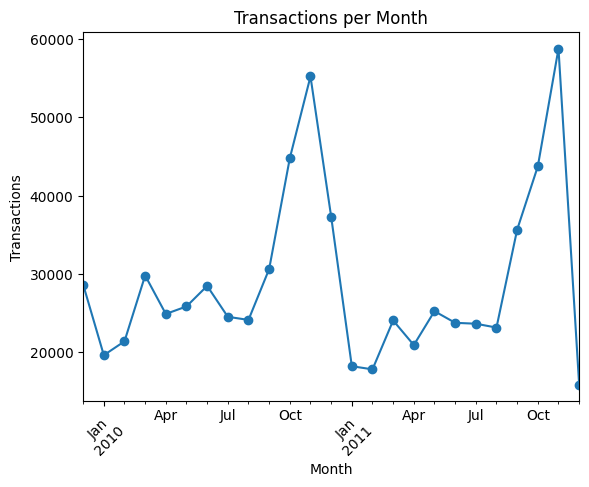

In [19]:
monthly = df.groupby(df['InvoiceDate'].dt.to_period('M')).size()

monthly.plot(kind='line', marker='o')
plt.xlabel('Month')
plt.ylabel('Transactions')
plt.title('Transactions per Month')
plt.xticks(rotation=45)
plt.show()

In [20]:
customer_spend = df.groupby('Customer ID')['TotalPrice'].sum()

customer_spend.head()

Customer ID
12346.0    77556.46
12608.0      415.79
12745.0      723.85
12746.0      254.55
12747.0     9276.54
Name: TotalPrice, dtype: float64

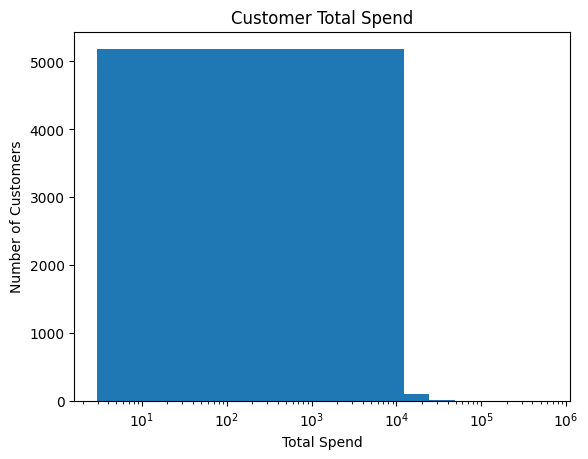

In [21]:
plt.hist(customer_spend, bins=50)
plt.xscale('log')
plt.xlabel('Total Spend')
plt.ylabel('Number of Customers')
plt.title('Customer Total Spend')
plt.show()

In [22]:
order_count = df.groupby('Customer ID')['Invoice'].nunique()

top10_customers = order_count.sort_values(ascending=False).head(10)

print(top10_customers)

Customer ID
12748.0    336
17841.0    211
15311.0    208
13089.0    203
14606.0    192
17850.0    155
18102.0    145
13694.0    143
15061.0    127
14527.0    122
Name: Invoice, dtype: int64


In [23]:
unique_customers = df['Customer ID'].nunique()

print("Unique customers:", unique_customers)

Unique customers: 5350


In [26]:
spend = customer_spend.sort_values(ascending=False)

cum = spend.cumsum()
total = spend.sum()

customers_80 = (cum <= total * 0.80).sum()

percentage = customers_80 / len(spend) * 100

print("Customers driving 80% revenue:", percentage, "%")

Customers driving 80% revenue: 24.299065420560748 %


# STEP : 2

In [27]:
reference_date = pd.Timestamp('2011-12-31')

In [28]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

In [29]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm = rfm.reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,346,12,77556.46
1,12608.0,425,1,415.79
2,12745.0,507,2,723.85
3,12746.0,561,1,254.55
4,12747.0,23,26,9276.54


In [30]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5350.000000,5350.000000,5350.000000,5350.000000
mean,15557.362617,223.546168,6.269346,2751.990190
std,1581.161762,209.973818,11.995550,12080.466564
min,12346.000000,21.000000,1.000000,2.950000
25%,14191.250000,46.000000,1.000000,336.167500
50%,15565.500000,119.000000,3.000000,849.910000
75%,16922.750000,402.000000,7.000000,2214.905000
max,18287.000000,759.000000,336.000000,608821.650000


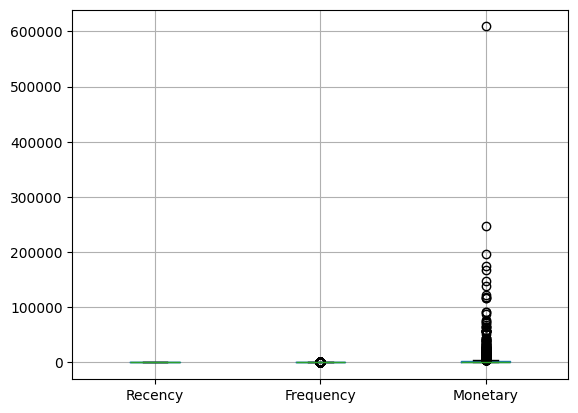

In [31]:
rfm[['Recency', 'Frequency', 'Monetary']].boxplot()
plt.show()

In [32]:
def cap_outliers(x):
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 3 * IQR
    return x.clip(upper=upper)

In [33]:
rfm['Recency'] = cap_outliers(rfm['Recency'])
rfm['Frequency'] = cap_outliers(rfm['Frequency'])
rfm['Monetary'] = cap_outliers(rfm['Monetary'])

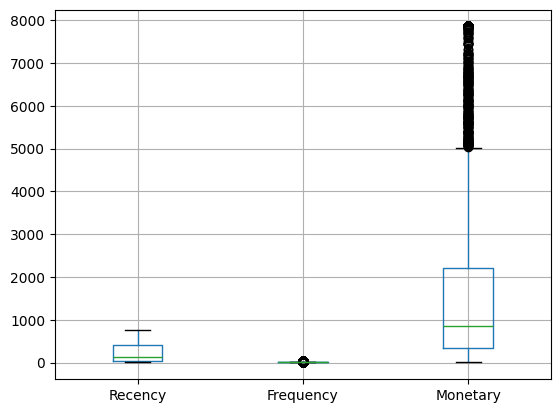

In [34]:
rfm[['Recency', 'Frequency', 'Monetary']].boxplot()
plt.show()

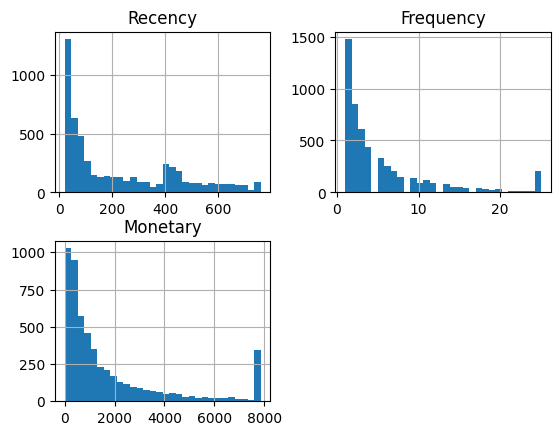

In [35]:
rfm[['Recency', 'Frequency', 'Monetary']].hist(bins=30)
plt.show()

In [36]:
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

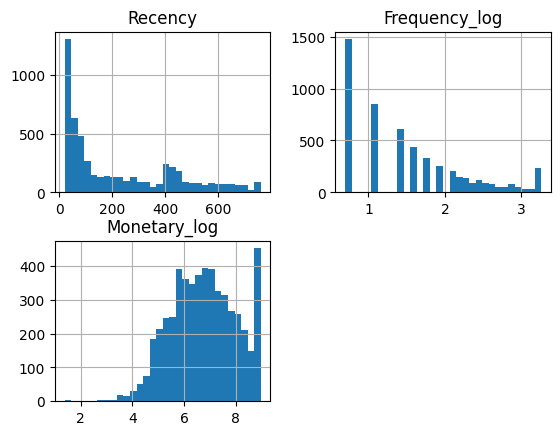

In [37]:
rfm[['Recency', 'Frequency_log', 'Monetary_log']].hist(bins=30)
plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler

features = rfm[['Recency', 'Frequency_log', 'Monetary_log']]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(features)

In [39]:
print(rfm_scaled.mean(axis=0))
print(rfm_scaled.std(axis=0))

[-2.22459642e-17  3.92790681e-16  3.21404378e-16]
[1. 1. 1.]


# STEP : 3

In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [41]:
inertia = []
silhouette = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = model.fit_predict(rfm_scaled)
    
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(rfm_scaled, labels))

In [42]:
results = pd.DataFrame({
    'K': range(2, 11),
    'Inertia': inertia,
    'Silhouette': silhouette
})

print(results)

    K      Inertia  Silhouette
0   2  7644.706253    0.433091
1   3  4903.889426    0.409523
2   4  3773.791621    0.373525
3   5  2969.205917    0.383819
4   6  2562.196718    0.353965
5   7  2258.052194    0.345668
6   8  2056.307509    0.345983
7   9  1874.773638    0.321326
8  10  1748.593656    0.316991


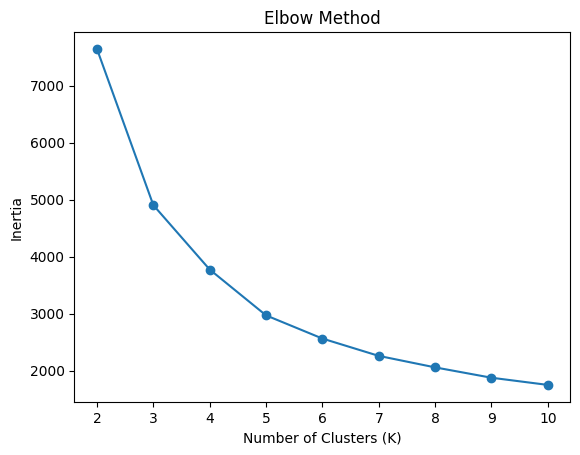

In [43]:
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

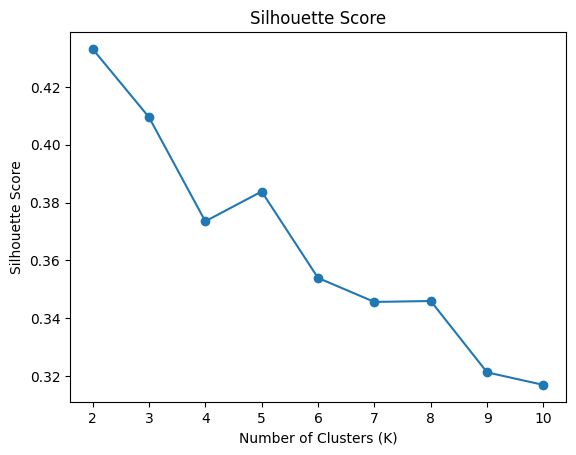

In [44]:
plt.plot(range(2, 11), silhouette, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

In [45]:
best_k = results.loc[results['Silhouette'].idxmax(), 'K']

print("Best K:", best_k)

Best K: 2


In [46]:
k_optimal = 4

In [47]:
k_optimal = 4

kmeans = KMeans(
    n_clusters=k_optimal,
    init='k-means++',
    n_init=20,
    max_iter=500,
    random_state=42
)

rfm['KMeans_Cluster'] = kmeans.fit_predict(rfm_scaled)

In [48]:
print(rfm.head())
print(rfm['KMeans_Cluster'].value_counts())

   Customer ID  Recency  Frequency   Monetary  Frequency_log  Monetary_log  \
0      12346.0      346         12  7851.1175       2.564949      8.968539   
1      12608.0      425          1   415.7900       0.693147      6.032582   
2      12745.0      507          2   723.8500       1.098612      6.585965   
3      12746.0      561          1   254.5500       0.693147      5.543418   
4      12747.0       23         25  7851.1175       3.258097      8.968539   

   KMeans_Cluster  
0               0  
1               2  
2               2  
3               2  
4               0  
KMeans_Cluster
3    1684
2    1419
1    1138
0    1109
Name: count, dtype: int64


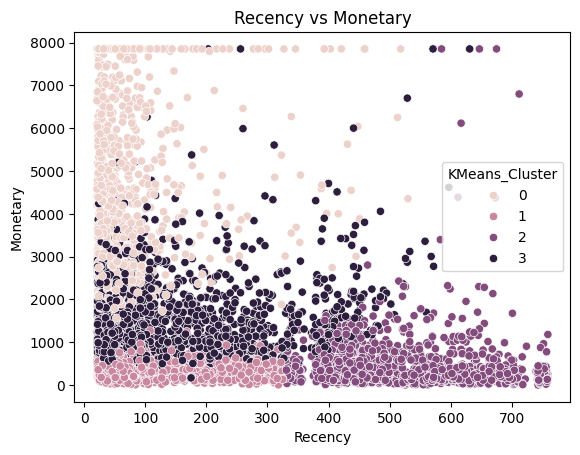

In [49]:
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='KMeans_Cluster'
)

plt.title('Recency vs Monetary')
plt.show()

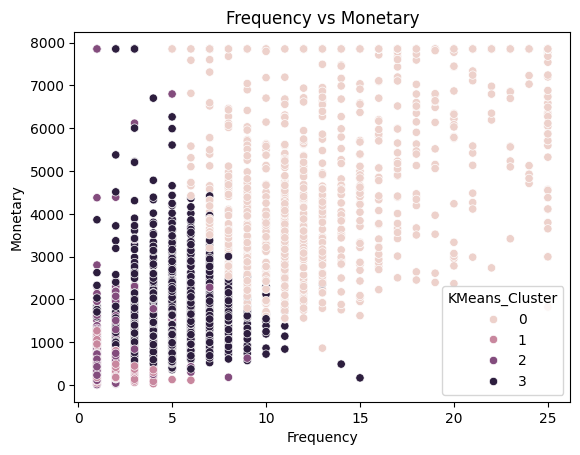

In [50]:
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='KMeans_Cluster'
)

plt.title('Frequency vs Monetary')
plt.show()

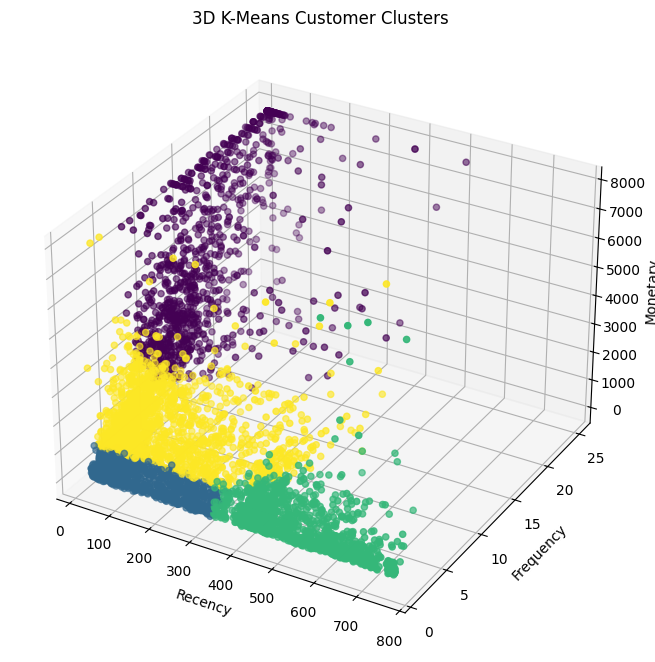

In [54]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 12))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['KMeans_Cluster']
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.title('3D K-Means Customer Clusters')
plt.show()

In [55]:
cluster_profile = rfm.groupby('KMeans_Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

print(cluster_profile)

                   Recency  Frequency     Monetary
KMeans_Cluster                                    
0                65.120830  15.138864  5232.563763
1               130.949033   1.636204   362.880000
2               521.002114   1.606765   455.246831
3               139.804632   4.774941  1551.429702


In [56]:
cluster_profile = cluster_profile.sort_values(
    'Monetary',
    ascending=False
)

cluster_profile

,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,65.120830,15.138864,5232.563763
3,139.804632,4.774941,1551.429702
2,521.002114,1.606765,455.246831
1,130.949033,1.636204,362.880000


# STEP : 4

In [57]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [58]:
Z = linkage(rfm_scaled, method='ward')

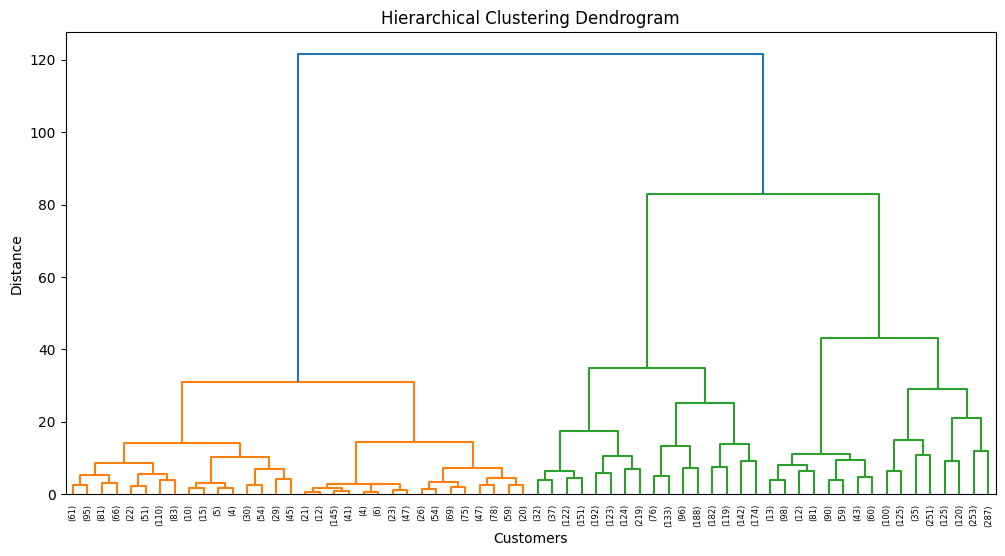

In [59]:
plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode='level',
    p=5
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

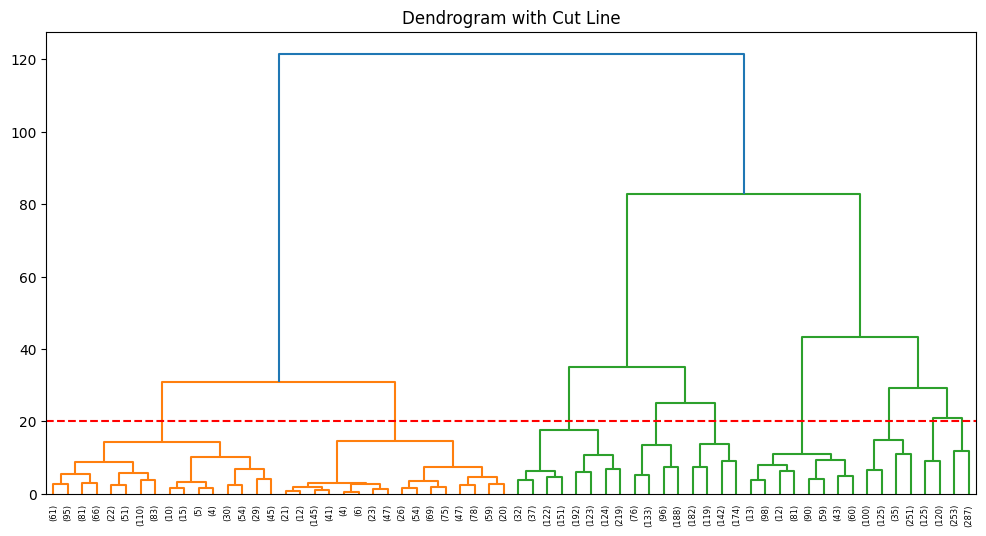

In [60]:
plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode='level',
    p=5
)

plt.axhline(y=20, color='red', linestyle='--')

plt.title('Dendrogram with Cut Line')
plt.show()

In [61]:
n_chosen = 4

In [62]:
models = {}

for method in ['ward', 'complete', 'average']:
    model = AgglomerativeClustering(
        n_clusters=n_chosen,
        linkage=method
    )
    
    labels = model.fit_predict(rfm_scaled)
    models[method] = labels

In [63]:
for method, labels in models.items():
    score = silhouette_score(rfm_scaled, labels)
    print(method, ":", score)

ward : 0.37078346017224256
complete : 0.30747257961844815
average : 0.3638730934746264


In [64]:
scores = {
    method: silhouette_score(rfm_scaled, labels)
    for method, labels in models.items()
}

best_method = max(scores, key=scores.get)

print("Best linkage:", best_method)
print("Best silhouette:", scores[best_method])

Best linkage: ward
Best silhouette: 0.37078346017224256


In [65]:
rfm['Agg_Cluster'] = models[best_method]

In [66]:
print(rfm.head())

   Customer ID  Recency  Frequency   Monetary  Frequency_log  Monetary_log  \
0      12346.0      346         12  7851.1175       2.564949      8.968539   
1      12608.0      425          1   415.7900       0.693147      6.032582   
2      12745.0      507          2   723.8500       1.098612      6.585965   
3      12746.0      561          1   254.5500       0.693147      5.543418   
4      12747.0       23         25  7851.1175       3.258097      8.968539   

   KMeans_Cluster  Agg_Cluster  
0               0            1  
1               2            2  
2               2            3  
3               2            2  
4               0            1  


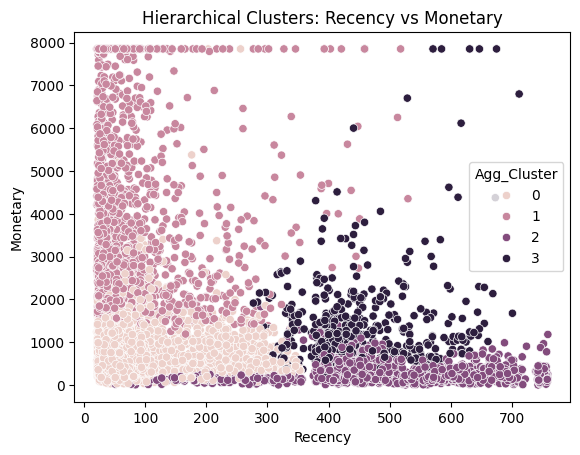

In [67]:
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Agg_Cluster'
)

plt.title('Hierarchical Clusters: Recency vs Monetary')
plt.show()

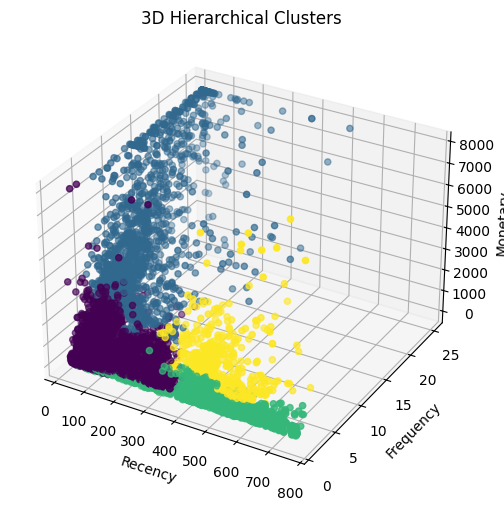

In [68]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Agg_Cluster']
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.title('3D Hierarchical Clusters')
plt.show()

In [69]:
agg_profile = rfm.groupby('Agg_Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

agg_profile = agg_profile.sort_values(
    'Monetary',
    ascending=False
)

print(agg_profile)

                Recency  Frequency     Monetary
Agg_Cluster                                    
1             77.812500  12.909946  4498.759183
3            454.892544   4.008772  1455.760779
0            109.342180   2.994787   824.218595
2            495.404321   1.246142   291.197308


In [70]:
print("K-Means Profile")
print(
    rfm.groupby('KMeans_Cluster')[
        ['Recency', 'Frequency', 'Monetary']
    ].mean()
)

print("\nHierarchical Profile")
print(agg_profile)

K-Means Profile
                   Recency  Frequency     Monetary
KMeans_Cluster                                    
0                65.120830  15.138864  5232.563763
1               130.949033   1.636204   362.880000
2               521.002114   1.606765   455.246831
3               139.804632   4.774941  1551.429702

Hierarchical Profile
                Recency  Frequency     Monetary
Agg_Cluster                                    
1             77.812500  12.909946  4498.759183
3            454.892544   4.008772  1455.760779
0            109.342180   2.994787   824.218595
2            495.404321   1.246142   291.197308


# STEP : 5

In [71]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [72]:
min_pts = 5

neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors.fit(rfm_scaled)

distances, indices = neighbors.kneighbors(rfm_scaled)

In [73]:
k_distances = distances[:, -1]
k_distances = np.sort(k_distances)

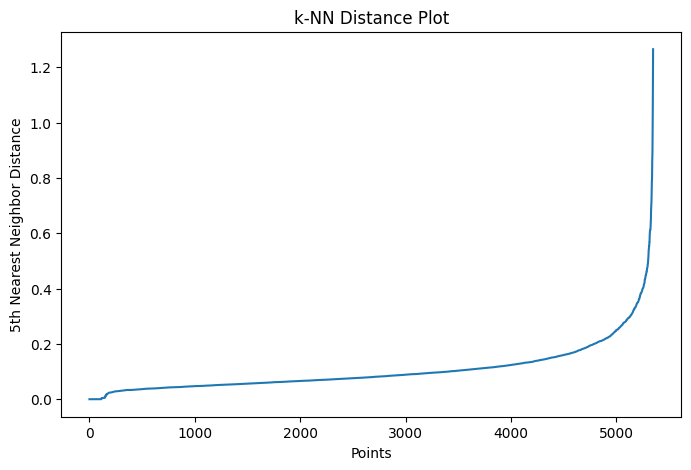

In [74]:
plt.figure(figsize=(8,5))

plt.plot(k_distances)

plt.xlabel('Points')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('k-NN Distance Plot')

plt.show()

In [75]:
optimal_eps = 0.7

In [76]:
optimal_eps = 0.7

dbscan = DBSCAN(
    eps=optimal_eps,
    min_samples=5,
    metric='euclidean'
)

labels = dbscan.fit_predict(rfm_scaled)

rfm['DBSCAN_Cluster'] = labels

In [77]:
print(rfm['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    5344
-1       6
Name: count, dtype: int64


In [78]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Number of clusters:", n_clusters)

Number of clusters: 1


In [79]:
noise_count = sum(labels == -1)

noise_percent = noise_count / len(labels) * 100

print("Noise points:", noise_count)
print("Noise percentage:", noise_percent)

Noise points: 6
Noise percentage: 0.11214953271028037


In [80]:
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [3, 5, 8, 10]

results = []

for eps in eps_values:
    for ms in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=ms
        )

        labels = model.fit_predict(rfm_scaled)

        # Remove noise for silhouette
        mask = labels != -1
        unique_clusters = set(labels[mask])

        if len(unique_clusters) >= 2:
            score = silhouette_score(
                rfm_scaled[mask],
                labels[mask]
            )
        else:
            score = np.nan

        results.append({
            'eps': eps,
            'min_samples': ms,
            'silhouette': score
        })

In [81]:
dbscan_results = pd.DataFrame(results)

print(dbscan_results)

    eps  min_samples  silhouette
0   0.3            3    0.005152
1   0.3            5    0.105491
2   0.3            8    0.198689
3   0.3           10    0.201054
4   0.5            3    0.304084
5   0.5            5    0.333463
6   0.5            8    0.333440
7   0.5           10    0.333265
8   0.7            3         NaN
9   0.7            5         NaN
10  0.7            8         NaN
11  0.7           10         NaN
12  1.0            3         NaN
13  1.0            5         NaN
14  1.0            8         NaN
15  1.0           10         NaN
16  1.5            3         NaN
17  1.5            5         NaN
18  1.5            8         NaN
19  1.5           10         NaN


In [82]:
best = dbscan_results.loc[
    dbscan_results['silhouette'].idxmax()
]

print(best)

eps            0.500000
min_samples    5.000000
silhouette     0.333463
Name: 5, dtype: float64


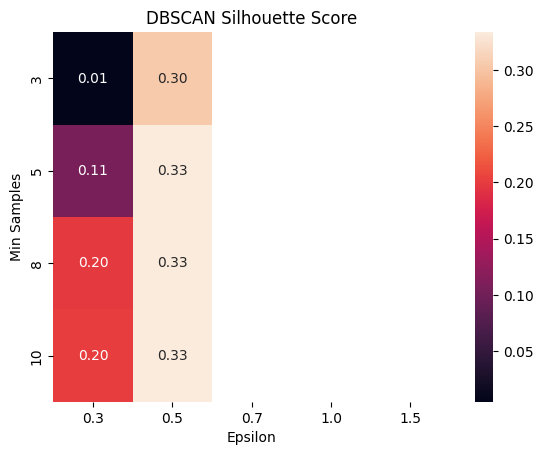

In [83]:
heatmap_data = dbscan_results.pivot(
    index='min_samples',
    columns='eps',
    values='silhouette'
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f'
)

plt.title('DBSCAN Silhouette Score')
plt.xlabel('Epsilon')
plt.ylabel('Min Samples')
plt.show()

In [84]:
best_eps = best['eps']
best_min_samples = int(best['min_samples'])

dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

In [85]:
print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)

Best eps: 0.5
Best min_samples: 5


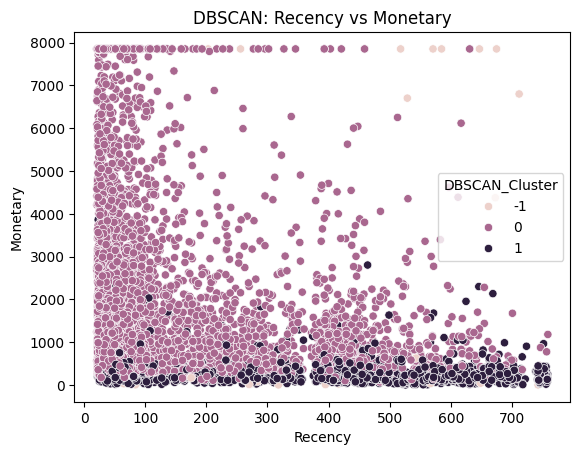

In [86]:
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='DBSCAN_Cluster'
)

plt.title('DBSCAN: Recency vs Monetary')
plt.show()

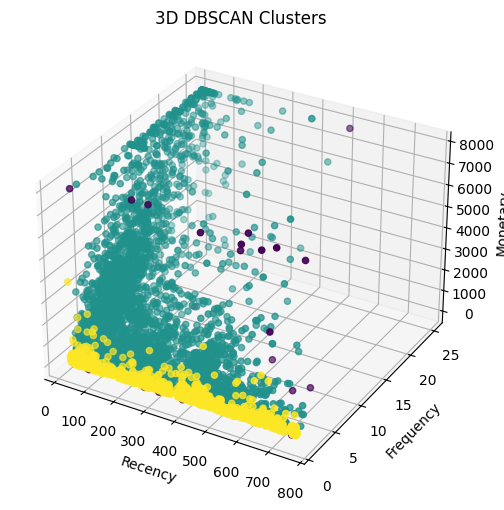

In [87]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['DBSCAN_Cluster']
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.title('3D DBSCAN Clusters')
plt.show()

In [88]:
dbscan_profile = rfm[rfm['DBSCAN_Cluster'] != -1].groupby(
    'DBSCAN_Cluster'
)[['Recency', 'Frequency', 'Monetary']].mean()

print(dbscan_profile)

                   Recency  Frequency     Monetary
DBSCAN_Cluster                                    
0               163.052863   7.100026  2316.995172
1               378.873720   1.000000   302.378922


# STEP : 6

In [89]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [90]:
km_labels = rfm['KMeans_Cluster']

km_sil = silhouette_score(rfm_scaled, km_labels)
km_db = davies_bouldin_score(rfm_scaled, km_labels)
km_ch = calinski_harabasz_score(rfm_scaled, km_labels)

print("K-Means")
print("Clusters:", len(set(km_labels)))
print("Silhouette:", km_sil)
print("Davies-Bouldin:", km_db)
print("Calinski-Harabasz:", km_ch)

K-Means
Clusters: 4
Silhouette: 0.373523425026743
Davies-Bouldin: 0.9053691309625893
Calinski-Harabasz: 5796.96536450453


In [91]:
agg_labels = rfm['Agg_Cluster']

agg_sil = silhouette_score(rfm_scaled, agg_labels)
agg_db = davies_bouldin_score(rfm_scaled, agg_labels)
agg_ch = calinski_harabasz_score(rfm_scaled, agg_labels)

print("Agglomerative")
print("Clusters:", len(set(agg_labels)))
print("Silhouette:", agg_sil)
print("Davies-Bouldin:", agg_db)
print("Calinski-Harabasz:", agg_ch)

Agglomerative
Clusters: 4
Silhouette: 0.37078346017224256
Davies-Bouldin: 0.8785625775432079
Calinski-Harabasz: 4867.134686781118


In [92]:
db_labels = rfm['DBSCAN_Cluster']

mask = db_labels != -1

db_sil = silhouette_score(
    rfm_scaled[mask],
    db_labels[mask]
)

db_db = davies_bouldin_score(
    rfm_scaled[mask],
    db_labels[mask]
)

db_ch = calinski_harabasz_score(
    rfm_scaled[mask],
    db_labels[mask]
)

db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)

noise_percent = (db_labels == -1).mean() * 100

print("DBSCAN")
print("Clusters:", db_clusters)
print("Silhouette:", db_sil)
print("Davies-Bouldin:", db_db)
print("Calinski-Harabasz:", db_ch)
print("Noise %:", noise_percent)

DBSCAN
Clusters: 3
Silhouette: 0.3334630802839043
Davies-Bouldin: 1.027159821455402
Calinski-Harabasz: 3121.3716152342154
Noise %: 0.48598130841121495


In [93]:
comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'Agglomerative', 'DBSCAN'],
    
    'Clusters': [
        len(set(km_labels)),
        len(set(agg_labels)),
        db_clusters
    ],
    
    'Silhouette': [
        km_sil,
        agg_sil,
        db_sil
    ],
    
    'Davies_Bouldin': [
        km_db,
        agg_db,
        db_db
    ],
    
    'Calinski_Harabasz': [
        km_ch,
        agg_ch,
        db_ch
    ],
    
    'Noise_%': [
        0,
        0,
        noise_percent
    ]
})

comparison

,Algorithm,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,Noise_%
0,K-Means,4,0.373523,0.905369,5796.965365,0.000000
1,Agglomerative,4,0.370783,0.878563,4867.134687,0.000000
2,DBSCAN,3,0.333463,1.027160,3121.371615,0.485981


In [94]:
comparison.sort_values(
    'Silhouette',
    ascending=False
)

,Algorithm,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,Noise_%
0,K-Means,4,0.373523,0.905369,5796.965365,0.000000
1,Agglomerative,4,0.370783,0.878563,4867.134687,0.000000
2,DBSCAN,3,0.333463,1.027160,3121.371615,0.485981


In [95]:
random_states = [0, 7, 21, 42, 99]

scores = []

for seed in random_states:
    model = KMeans(
        n_clusters=k_optimal,
        init='k-means++',
        n_init=20,
        max_iter=500,
        random_state=seed
    )
    
    labels = model.fit_predict(rfm_scaled)
    
    score = silhouette_score(
        rfm_scaled,
        labels
    )
    
    scores.append(score)

print(scores)

[0.3735300189539833, 0.3735067018423129, 0.37346921393601173, 0.373523425026743, 0.37351801851081207]


In [96]:
print("Mean:", np.mean(scores))
print("Std:", np.std(scores))

Mean: 0.37350947565397263
Std: 2.1532731100727372e-05


In [97]:
kmeans_profile = rfm.groupby(
    'KMeans_Cluster'
)[['Recency', 'Frequency', 'Monetary']].mean()

kmeans_profile.sort_values(
    'Monetary',
    ascending=False
)

,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,65.120830,15.138864,5232.563763
3,139.804632,4.774941,1551.429702
2,521.002114,1.606765,455.246831
1,130.949033,1.636204,362.880000


# Business Recommendation – Customer Segmentation

## Recommended Algorithm

Based on the Silhouette Score, Davies-Bouldin Index and Calinski-Harabasz
Index, I recommend using [ALGORITHM NAME] for customer segmentation.
It provides well-separated and compact customer groups and is suitable
for targeted marketing campaigns.

## Customer Segments

### 1. Champions
These customers have low Recency, high Frequency and high Monetary value.
They are highly valuable and recently active customers.

**Action:** Invite them to an exclusive loyalty/reward program.

### 2. Loyal Customers
These customers purchase regularly and have good overall customer value.

**Action:** Provide loyalty points, personalized offers and early access
to new products.

### 3. At-Risk Customers
These customers previously showed good spending or purchasing frequency
but have high Recency.

**Action:** Send personalized discount coupons with a limited expiry period.

### 4. Hibernating Customers
These customers have high Recency and relatively low Frequency and Monetary
values.

**Action:** Use reactivation campaigns and low-cost promotional offers.

## Additional Data

Beyond RFM, the company should collect product preferences, customer
demographics, purchase channels, campaign response history and website/app
behavior. These additional features could improve segmentation quality
and make marketing campaigns more personalized.

# STEP : 7

In [98]:
import joblib

In [99]:
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [100]:
joblib.dump(scaler, 'rfm_scaler.pkl')

['rfm_scaler.pkl']

In [101]:
joblib.dump(kmeans, 'customer_segmentation_model.pkl')

['customer_segmentation_model.pkl']

In [102]:
def predict_segment(recency, frequency, monetary):

    # Log transformation
    frequency_log = np.log1p(frequency)
    monetary_log = np.log1p(monetary)

    # Create input
    new_customer = [[
        recency,
        frequency_log,
        monetary_log
    ]]

    # Scale
    scaled = scaler.transform(new_customer)

    # Predict cluster
    cluster = kmeans.predict(scaled)[0]

    # Persona
    persona = {
        0: 'Champions',
        1: 'Loyal Customers',
        2: 'At-Risk Customers',
        3: 'Hibernating Customers'
    }

    return cluster, persona.get(cluster, 'Other')

In [103]:
persona = {
    2: 'Champions',
    0: 'Loyal Customers',
    3: 'At-Risk Customers',
    1: 'Hibernating Customers'
}

In [104]:
cluster, persona = predict_segment(
    recency=20,
    frequency=15,
    monetary=5000
)

print("Cluster:", cluster)
print("Persona:", persona)

Cluster: 0
Persona: Champions


C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [105]:
test_customers = [
    [10, 20, 8000],
    [30, 12, 5000],
    [100, 5, 1500],
    [250, 2, 500],
    [400, 1, 200]
]

for customer in test_customers:

    cluster, persona = predict_segment(
        customer[0],
        customer[1],
        customer[2]
    )

    print(
        "RFM:", customer,
        "| Cluster:", cluster,
        "| Persona:", persona
    )

RFM: [10, 20, 8000] | Cluster: 0 | Persona: Champions
RFM: [30, 12, 5000] | Cluster: 0 | Persona: Champions
RFM: [100, 5, 1500] | Cluster: 3 | Persona: Hibernating Customers
RFM: [250, 2, 500] | Cluster: 1 | Persona: Loyal Customers
RFM: [400, 1, 200] | Cluster: 2 | Persona: At-Risk Customers


C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Purvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-pac